# Notebook 4: BERT Fine-tuning (Main Model)
## Boris Letić (E2 126/2025) | Bitcoin Sentiment Analysis

**Purpose:** Train main deep learning model using BERT transformer

**Output:** Trained model ready for deployment

## 1. Setup

In [81]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertModel
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score,
    classification_report, 
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
import os
import json
import time

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")
print(f"CUDA: {torch.cuda.is_available()}")

Device: cuda
CUDA: True


## 2. Load Data

In [82]:
df = pd.read_csv('data/processed/tweets_preprocessed.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
print(f"Loaded {len(df):,} tweets")

Loaded 12,120 tweets


## 3. Train/Val/Test Split (60/20/20)

In [83]:
from sklearn.model_selection import train_test_split

print("="*70)
print("TRAIN/VAL/TEST SPLIT")
print("="*70)

print(f"\nDataset: {len(df):,} unique tweets")

# Stratified split (60/20/20)
train_val, test = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['sentiment'],
    shuffle=True
)

train, val = train_test_split(
    train_val, 
    test_size=0.25,  # 0.25 * 0.8 = 0.2 of total
    random_state=42,
    stratify=train_val['sentiment'],
    shuffle=True
)

print(f"\nStratified split:")
print(f"  Train: {len(train):,} tweets (60%)")
print(f"  Val:   {len(val):,} tweets (20%)")
print(f"  Test:  {len(test):,} tweets (20%)")

print(f"\nSentiment distribution:")
for name, split in [('Train', train), ('Val', val), ('Test', test)]:
    dist = split['sentiment'].value_counts(normalize=True) * 100
    print(f"  {name}: Pos={dist.get('positive',0):.1f}% Neu={dist.get('neutral',0):.1f}% Neg={dist.get('negative',0):.1f}%")

print("\n✓ No data leakage (stratified split with shuffle)")
print("="*70)

TRAIN/VAL/TEST SPLIT

Dataset: 12,120 unique tweets

Stratified split:
  Train: 7,272 tweets (60%)
  Val:   2,424 tweets (20%)
  Test:  2,424 tweets (20%)

Sentiment distribution:
  Train: Pos=35.1% Neu=47.2% Neg=17.7%
  Val: Pos=35.1% Neu=47.2% Neg=17.7%
  Test: Pos=35.1% Neu=47.2% Neg=17.7%

✓ No data leakage (stratified split with shuffle)


## 4. BERT Dataset

In [84]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # UPDATED: Use __call__ instead of encode_plus
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
y_train = train['sentiment'].map(label_map).values
y_val = val['sentiment'].map(label_map).values
y_test = test['sentiment'].map(label_map).values

print("✓ Dataset class defined")

✓ Dataset class defined


## 5. Tokenizer & DataLoaders

In [85]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_ds = TweetDataset(train['text_cleaned'].values, y_train, tokenizer)
val_ds = TweetDataset(val['text_cleaned'].values, y_val, tokenizer)
test_ds = TweetDataset(test['text_cleaned'].values, y_test, tokenizer)

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"✓ DataLoaders ready: {len(train_loader)} train batches")

✓ DataLoaders ready: 455 train batches


## 6. BERT Model Architecture

In [86]:
class BERTSentimentClassifier(nn.Module):
    def __init__(self, n_classes=3, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        
        # FREEZE embeddings
        for param in self.bert.embeddings.parameters():
            param.requires_grad = False
        
        # FREEZE first 8 encoder layers
        for layer in self.bert.encoder.layer[:8]:
            for param in layer.parameters():
                param.requires_grad = False
        
        # UNFREEZE last 4 encoder layers (8-11)
        for layer in self.bert.encoder.layer[8:]:
            for param in layer.parameters():
                param.requires_grad = True
        
        # UNFREEZE pooler
        for param in self.bert.pooler.parameters():
            param.requires_grad = True
        
        # Classifier head
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(768, n_classes)
    
    def forward(self, input_ids, attention_mask):
        # Fine-tune last 4 layers (NO torch.no_grad!)
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.pooler_output
        return self.fc(self.drop(pooled))


# Initialize model
model = BERTSentimentClassifier().to(device)

# Discriminative learning rates
optimizer = AdamW([
    {'params': model.bert.encoder.layer[8].parameters(), 'lr': 5e-6},
    {'params': model.bert.encoder.layer[9].parameters(), 'lr': 5e-6},
    {'params': model.bert.encoder.layer[10].parameters(), 'lr': 5e-6},
    {'params': model.bert.encoder.layer[11].parameters(), 'lr': 5e-6},
    {'params': model.bert.pooler.parameters(), 'lr': 5e-6},
    {'params': model.fc.parameters(), 'lr': 2e-4},
    {'params': model.drop.parameters(), 'lr': 2e-4}
], weight_decay=0.01)

# Learning rate scheduler with warmup
from transformers import get_linear_schedule_with_warmup

EPOCHS = 3
num_training_steps = len(train_loader) * EPOCHS
num_warmup_steps = num_training_steps // 10

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Print summary
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"\n{'='*70}")
print(f"✓ BERT model initialized (PARTIALLY UNFROZEN)")
print(f"{'='*70}")
print(f"  Total parameters:     {total:,}")
print(f"  Trainable:            {trainable:,}")
print(f"  Frozen:               {total - trainable:,}")
print(f"  Trainable %:          {100 * trainable / total:.2f}%")
print(f"\n  Strategy:")
print(f"    • Embeddings:         FROZEN")
print(f"    • Encoder layers 0-7: FROZEN")
print(f"    • Encoder layers 8-11: TRAINABLE (last 4)")
print(f"    • Pooler:             TRAINABLE")
print(f"    • Classifier:         TRAINABLE")
print(f"{'='*70}\n")

# Verify layer status
for i, layer in enumerate(model.bert.encoder.layer):
    trainable_params = sum(p.numel() for p in layer.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in layer.parameters())
    status = "✓ TRAINABLE" if trainable_params > 0 else "✗ FROZEN"
    print(f"  Layer {i:2d}: {status} ({trainable_params:,}/{total_params:,})")
print(f"{'='*70}\n")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✓ BERT model initialized (PARTIALLY UNFROZEN)
  Total parameters:     109,484,547
  Trainable:            28,944,387
  Frozen:               80,540,160
  Trainable %:          26.44%

  Strategy:
    • Embeddings:         FROZEN
    • Encoder layers 0-7: FROZEN
    • Encoder layers 8-11: TRAINABLE (last 4)
    • Pooler:             TRAINABLE
    • Classifier:         TRAINABLE

  Layer  0: ✗ FROZEN (0/7,087,872)
  Layer  1: ✗ FROZEN (0/7,087,872)
  Layer  2: ✗ FROZEN (0/7,087,872)
  Layer  3: ✗ FROZEN (0/7,087,872)
  Layer  4: ✗ FROZEN (0/7,087,872)
  Layer  5: ✗ FROZEN (0/7,087,872)
  Layer  6: ✗ FROZEN (0/7,087,872)
  Layer  7: ✗ FROZEN (0/7,087,872)
  Layer  8: ✓ TRAINABLE (7,087,872/7,087,872)
  Layer  9: ✓ TRAINABLE (7,087,872/7,087,872)
  Layer 10: ✓ TRAINABLE (7,087,872/7,087,872)
  Layer 11: ✓ TRAINABLE (7,087,872/7,087,872)



## 7. Training & Evaluation Functions

In [87]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for batch in pbar:
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        # Forward pass
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # Track metrics
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Update progress bar
        current_lr = scheduler.get_last_lr()[0]
        pbar.set_postfix({
            'loss': f'{loss.item():.3f}', 
            'acc': f'{correct/total:.3f}',
            'lr': f'{current_lr:.2e}'
        })
    
    return total_loss / len(loader), correct / total


def evaluate(model, loader, device, return_predictions=False):
    """Evaluate model on validation/test set"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    if return_predictions:
        return all_preds, all_labels
    else:
        accuracy = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='weighted')
        precision = precision_score(all_labels, all_preds, average='weighted')
        recall = recall_score(all_labels, all_preds, average='weighted')
        return accuracy, f1, precision, recall


print("✓ Training functions defined")

✓ Training functions defined


## 8. Training Loop

In [88]:
import time

best_val_acc = 0.0
patience = 3
patience_counter = 0

history = {
    'train_loss': [],
    'train_acc': [],
    'val_acc': [],
    'val_f1': []
}

print("="*70)
print("TRAINING BERT WITH UNFROZEN LAST 4 LAYERS")
print("="*70)
print(f"Epochs: {EPOCHS}")
print(f"Patience: {patience}")
print(f"Warmup steps: {num_warmup_steps}")
print(f"Total steps: {num_training_steps}")
print("="*70)
print()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    
    print(f"Epoch {epoch}/{EPOCHS}")
    print("-"*70)
    
    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device
    )
    
    # Validate
    val_acc, val_f1, val_precision, val_recall = evaluate(
        model, val_loader, device, return_predictions=False
    )
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    epoch_time = time.time() - epoch_start
    
    print(f"Epoch {epoch} Summary:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Train Acc:  {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"  Val Acc:    {val_acc:.4f} ({val_acc*100:.2f}%)")
    print(f"  Val F1:     {val_f1:.4f}")
    print(f"  Time:       {epoch_time:.1f}s")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_f1': val_f1,
        }, 'models/bert_sentiment_best.pt')
        print(f"  ✓ Best model saved (val_acc: {val_acc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")
    
    print()
    
    if patience_counter >= patience:
        print(f"Early stopping after {epoch} epochs")
        break

print("="*70)
print("TRAINING COMPLETE")
print(f"Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print("="*70)

TRAINING BERT WITH UNFROZEN LAST 4 LAYERS
Epochs: 3
Patience: 3
Warmup steps: 136
Total steps: 1365

Epoch 1/3
----------------------------------------------------------------------


Training: 100%|██████████| 455/455 [00:44<00:00, 10.28it/s, loss=0.413, acc=0.748, lr=3.70e-06]


Epoch 1 Summary:
  Train Loss: 0.6996
  Train Acc:  0.7478 (74.78%)
  Val Acc:    0.9422 (94.22%)
  Val F1:     0.9410
  Time:       52.4s
  ✓ Best model saved (val_acc: 0.9422)

Epoch 2/3
----------------------------------------------------------------------


Training: 100%|██████████| 455/455 [00:43<00:00, 10.37it/s, loss=0.489, acc=0.950, lr=1.85e-06]


Epoch 2 Summary:
  Train Loss: 0.4007
  Train Acc:  0.9501 (95.01%)
  Val Acc:    0.9666 (96.66%)
  Val F1:     0.9667
  Time:       52.0s
  ✓ Best model saved (val_acc: 0.9666)

Epoch 3/3
----------------------------------------------------------------------


Training: 100%|██████████| 455/455 [00:44<00:00, 10.31it/s, loss=0.311, acc=0.965, lr=0.00e+00]


Epoch 3 Summary:
  Train Loss: 0.3720
  Train Acc:  0.9652 (96.52%)
  Val Acc:    0.9686 (96.86%)
  Val F1:     0.9688
  Time:       52.3s
  ✓ Best model saved (val_acc: 0.9686)

TRAINING COMPLETE
Best validation accuracy: 0.9686 (96.86%)


## 9. Test Set Evaluation

In [93]:
print("="*70)
print("TEST SET EVALUATION")
print("="*70)

# Load best model
checkpoint = torch.load('models/bert_sentiment_best.pt')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model from epoch {checkpoint['epoch']}")

# Evaluate
test_acc, test_f1, test_precision, test_recall = evaluate(
    model, test_loader, device, return_predictions=False
)

print(f"\nTest Performance:")
print(f"  Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  F1-Score:  {test_f1:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")

# Get predictions for detailed analysis
test_preds, test_labels = evaluate(
    model, test_loader, device, return_predictions=True
)

print(f"\nClassification Report:")
label_names = ['positive', 'neutral', 'negative']
print(classification_report(test_labels, test_preds, target_names=label_names, digits=4))

cm = confusion_matrix(test_labels, test_preds)
print(f"\nConfusion Matrix:")
print(cm)
print("="*70)


TEST SET EVALUATION
✓ Loaded best model from epoch 3



Test Performance:
  Accuracy:  0.9719 (97.19%)
  F1-Score:  0.9720
  Precision: 0.9722
  Recall:    0.9719



Classification Report:
              precision    recall  f1-score   support

    positive     0.9661    0.9707    0.9684       852
     neutral     0.9929    0.9834    0.9881      1144
    negative     0.9287    0.9439    0.9363       428

    accuracy                         0.9719      2424
   macro avg     0.9626    0.9660    0.9643      2424
weighted avg     0.9722    0.9719    0.9720      2424


Confusion Matrix:
[[ 827    4   21]
 [   9 1125   10]
 [  20    4  404]]


## 10. Training History & Confusion Matrix

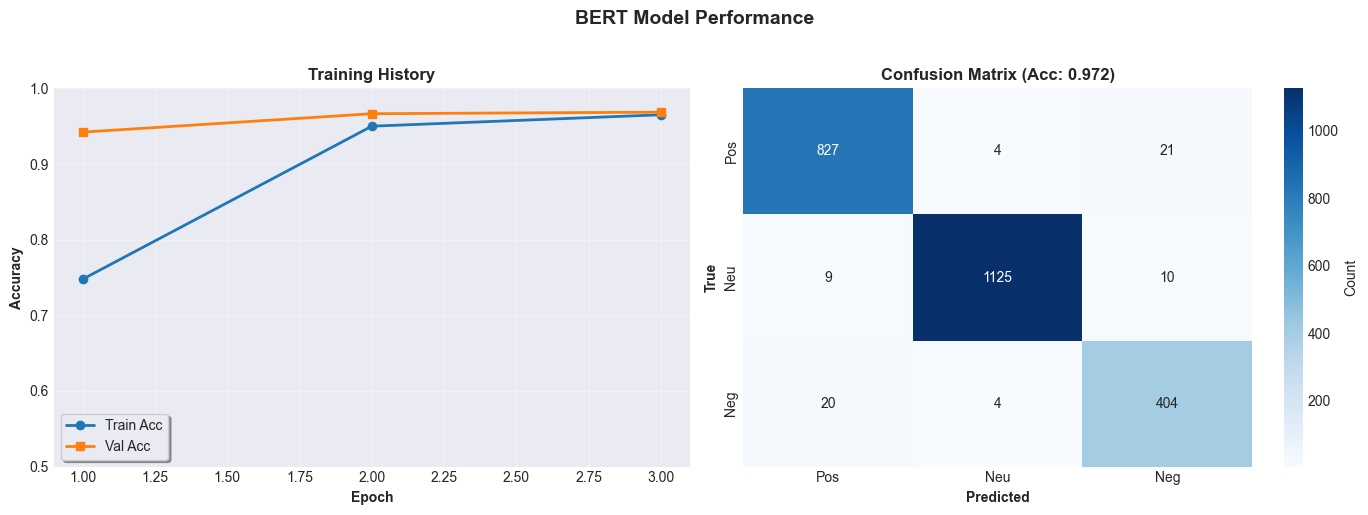

✓ Visualizations complete


In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training history
epochs_range = range(1, EPOCHS+1)
axes[0].plot(epochs_range, history['train_acc'], marker='o', label='Train Acc', linewidth=2)
axes[0].plot(epochs_range, history['val_acc'], marker='s', label='Val Acc', linewidth=2)
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Training History', fontweight='bold', fontsize=12)
axes[0].legend(frameon=True, shadow=True)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.5, 1.0])

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pos','Neu','Neg'],
            yticklabels=['Pos','Neu','Neg'],
            cbar_kws={'label': 'Count'},
            ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Acc: {test_acc:.3f})', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Predicted', fontweight='bold')
axes[1].set_ylabel('True', fontweight='bold')

plt.suptitle('BERT Model Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✓ Visualizations complete")

## 11. Comparison with VADER Baseline

In [95]:
# Load VADER metrics
try:
    with open('results/baseline/vader_metrics.json', 'r') as f:
        vader_metrics = json.load(f)
    
    vader_acc = vader_metrics['vader_lr']['accuracy']
    vader_f1 = vader_metrics['vader_lr']['f1']
    
    comparison = pd.DataFrame({
        'Model': ['VADER + LR (Baseline)', 'BERT (Main Model)'],
        'Accuracy': [vader_acc, test_acc],
        'F1-Score': [vader_f1, test_f1],
        'Type': ['Rule-based + ML', 'Transformer']
    })
    
    print("="*70)
    print("MODEL COMPARISON")
    print("="*70)
    print(f"\n{comparison.to_string(index=False)}")
    
    improvement = (test_acc - vader_acc) * 100
    print(f"\n✓ BERT improvement over baseline: {improvement:+.2f} percentage points")
    print("="*70)
    
except FileNotFoundError:
    print("VADER metrics not found. Run Notebook 3 first for comparison.")

MODEL COMPARISON

                Model  Accuracy  F1-Score            Type
VADER + LR (Baseline)  0.558993  0.549583 Rule-based + ML
    BERT (Main Model)  0.971947  0.972038     Transformer

✓ BERT improvement over baseline: +41.30 percentage points


## 12. Export Results

In [96]:
os.makedirs('results/bert', exist_ok=True)

# Save predictions
test_results = test.copy()
test_results['bert_pred_encoded'] = test_preds
test_results['bert_pred'] = [label_names[p] for p in test_preds]

test_results[['datetime','text','sentiment','bert_pred']].to_csv(
    'results/bert/bert_predictions.csv', index=False
)

# Save metrics
bert_metrics = {
    'test_accuracy': float(test_acc),
    'test_f1': float(test_f1),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'best_val_accuracy': float(best_val_acc),
    'epochs_trained': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': 2e-5
}

with open('results/bert/bert_metrics.json', 'w') as f:
    json.dump(bert_metrics, f, indent=2)

# Save history
with open('results/bert/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print("✓ Saved: results/bert/bert_predictions.csv")
print("✓ Saved: results/bert/bert_metrics.json")
print("✓ Saved: results/bert/training_history.json")
print("✓ Saved: models/bert_sentiment_best.pt")

✓ Saved: results/bert/bert_predictions.csv
✓ Saved: results/bert/bert_metrics.json
✓ Saved: results/bert/training_history.json
✓ Saved: models/bert_sentiment_best.pt
